In [8]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin

In [ ]:
#function3
def JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD):
    H_L = H_l
    H_R = H_r
    H_D = H_q

    T_L = T_l
    T_R = T_r
    T_D = T_12
    T_DR = T_RD
    T_DL = T_LD

    lx = Lx // 2

    # temperature
   

    kBT = KBT

    N = H_D.shape[0]
        

    EE = (E+epp) * np.eye(N)
    # ================= Right Lead =================
    inv_TR = np.linalg.inv(T_R)

    TT_R = np.block([
        [inv_TR @ (EE - H_R), -inv_TR @ T_R.conj().T],
        [np.eye(N), np.zeros((N, N))]
    ])

    eigval, eigvec = np.linalg.eig(TT_R)
    idx = np.argsort(np.abs(eigval))

    v = eigvec[:, idx]
    S1 = v[:N, :N]
    S2 = v[N:2*N, :N]

    g_R = np.linalg.inv(
        EE - H_R - T_R @ S1 @ np.linalg.inv(S2)
    )

    SigmaR = T_DR @ g_R @ T_DR.conj().T

    # ================= Left Lead =================
    inv_TL_dag = np.linalg.inv(T_L)

    TT_L = np.block([
        [inv_TL_dag @ (EE - H_L), -inv_TL_dag @ T_L.conj().T],
        [np.eye(N), np.zeros((N, N))]
    ])

    eigval, eigvec = np.linalg.eig(TT_L)
    idx = np.argsort(np.abs(eigval))

    v = eigvec[:, idx]
    S1 = v[:N, :N]
    S2 = v[N:2*N, :N]

    g_L = np.linalg.inv(
        EE - H_L - T_L @ S1 @ np.linalg.inv(S2)
    )

    SigmaL = T_DL @ g_L @ T_DL.conj().T

    # ================= Device Green Function =================
    G11 = np.linalg.inv(EE - H_D - SigmaL)
    GNN = np.linalg.inv(EE - H_D - SigmaR)

    Gii = G11
    for _ in range(2, lx):
        Gii = np.linalg.inv(
            EE - H_D - T_D.conj().T @ Gii @ T_D
        )

    Gkk = GNN
    for _ in range(Lx-1, lx, -1):
        Gkk = np.linalg.inv(
            EE - H_D - T_D @ Gkk @ T_D.conj().T
        )

    Sigma_i = T_D.conj().T @ Gii @ T_D
    Sigma_k = T_D @ Gkk @ T_D.conj().T

    Gll = np.linalg.inv(
        EE - H_D - Sigma_i - Sigma_k
    )

    # ================= Current Operator =================
    GFO_SN = Gll @ T_D.conj().T @ Gii
    GFOD_SN = Gii @ T_D @ Gll

    SIGM0 = np.array([[1,0,0,0],[0,1,0,0],[0,0,-1,0],
                    [0,0,0,-1]])

    current_matrix = SIGM0 @ (
        T_D @ (1j * GFO_SN)
        - T_D.conj().T @ (1j * GFOD_SN)
    )

    dc = np.real(np.trace(current_matrix))

    current = kBT / Delta * dc

    return current

In [19]:
#参数1
dela = 1
t = 200
af =100
a = 1
mu = 0
chaodaojiao=np.pi*1

#两边
hz=0
hc=2#两边的长度一样
h =hc * np.sqrt(mu**2 + dela**2)
saimanjiao = np.pi*0

#中间
mz=0
m = h
zhongjian_saimanjiao=np.pi*0

T_Tc=1e-3
Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
dianshubei=2
shumu=int(np.floor(5/ T_Tc))
KBT=2 * dela * T_Tc / 3.5

N=2
Lx=N
q=0
epp=1e-3j
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(m_xy,m_z,weizhi,chaodaojiao,Bjiao,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy
    elif weizhi==2:
        Delta_X=np.zeros((2,2))
    elif weizhi==3:
        Delta_X= Delta * np.exp(+1j*chaodaojiao) * 1j * sy
    HX_block=-(mu-2*t)*s0 + m_xy*np.sin(Bjiao)*sy+ m_xy*np.cos(Bjiao)*sx + m_z*sz
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(h,hz,1,chaodaojiao,0)
H_L_right_to_left_hop=H_hop(af)

#中间矩阵信息
H_center_to_L=H_hop(af)

H_center=H_onsite(m,mz,2,chaodaojiao,zhongjian_saimanjiao)
H_center_right_to_left_hop=H_hop(af)

H_R_to_center=H_hop(af)

#右边矩阵信息
H_R_onsite=H_onsite(h,hz,3,chaodaojiao,saimanjiao)
H_R_right_to_left_hop=H_hop(af)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center

#shumu*2*np.pi*KBT/Delta

Text(0.5, 1.0, 'J vs E\n$\\Delta = 1$ meV,  $\\mu = 0.0\\Delta$,  $T/T_c = 0.001$, chaodaojiao=3.14,eta=0.001j\n$hz = 0\\Delta$, $hc = 2.0\\Delta$,  $\\alpha = 100$meVÅ\n')

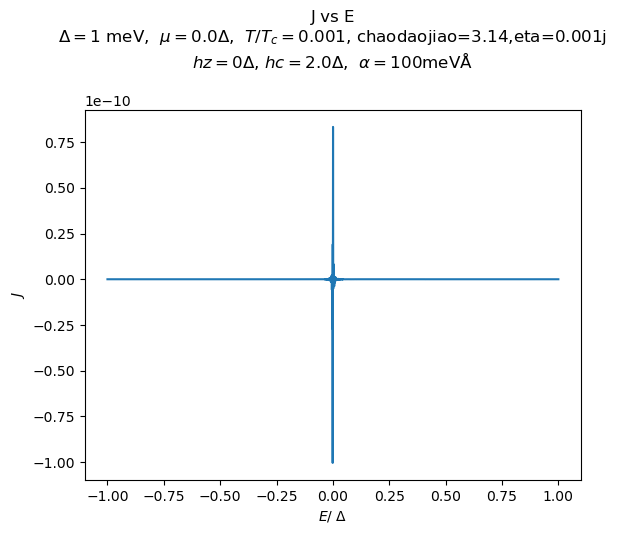

In [20]:
E_set=np.linspace(-1,1,5000)
J_shuchu=[]
for E in E_set:
    ll=JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD)
    J_shuchu.append(ll)

plt.plot(E_set,J_shuchu)
plt.ylabel(r"$J$")
plt.xlabel(r"$E$/ $\Delta$")
plt.title(
    f'J vs E\n'
    f'$\\Delta = {dela}$ meV,  $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$, chaodaojiao={chaodaojiao:.2f},eta={epp}\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)

Text(0.5, 1.0, 'J vs E\n$\\Delta = 1$ meV,  $\\mu = 0.0\\Delta$,  $T/T_c = 0.001$, chaodaojiao=3.14,eta=0.001j\n$hz = 0\\Delta$, $hc = 2.0\\Delta$,  $\\alpha = 100$meVÅ\n')

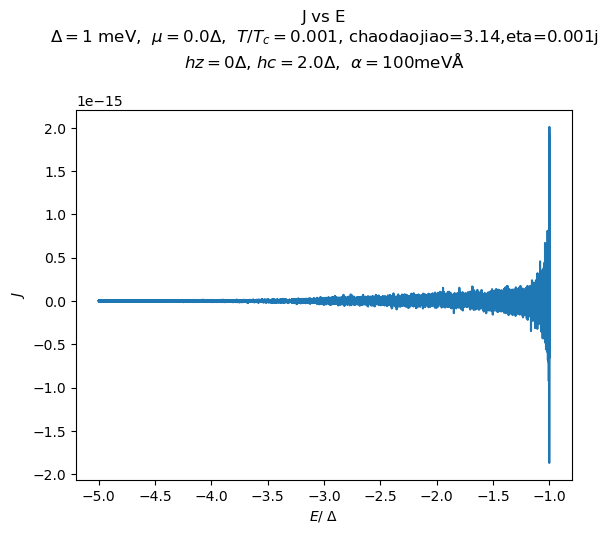

In [22]:
E_set=np.linspace(-5,-1,20000)
J_shuchu=[]
for E in E_set:
    ll=JoseCurrent_E(E,H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD)
    J_shuchu.append(ll)

plt.plot(E_set,J_shuchu)
plt.ylabel(r"$J$")
plt.xlabel(r"$E$/ $\Delta$")
plt.title(
    f'J vs E\n'
    f'$\\Delta = {dela}$ meV,  $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$, chaodaojiao={chaodaojiao:.2f},eta={epp}\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)

In [9]:
#ABs
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    #if max_err > check_tol:
    #    mag = np.abs(eigvals)
    #    print("Sorted |eigvals|:", np.sort(mag))
    #    raise RuntimeError(
    #        fr"Self-consistency violated: max |Δ| = {max_err}"
    #    )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

#current
def Gr_DD_666(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E+epp)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E+epp)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    f_E= 1/(1+np.exp((E - mu)/KBT))
    G_DD_wn_xiao=f_E*(G_DD_wn.conj()-G_DD_wn)
    return G_DD_wn_xiao , A_DD_wn , Sigma_R , Sigma_L 

def J_E(Gr_DD, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = Gr_DD[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = Gr_DD[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q1_q - G_q_q1 @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT
    #return np.trace(Jmat)*(-1j)*KBT


C:\Users\taoji\AppData\Local\Temp\ipykernel_14828\3856578026.py:78: RuntimeWarning: overflow encountered in exp
  f_E= 1/(1+np.exp((E - mu)/KBT))
c:\Users\taoji\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\taoji\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'J vs E\n$\\Delta = 1$ meV,  $\\mu = 0.0\\Delta$,  $T/T_c = 0.001$, chaodaojiao=3.14,eta=0.001j\n$hz = 0\\Delta$, $hc = 2.0\\Delta$,  $\\alpha = 100$meVÅ\n')

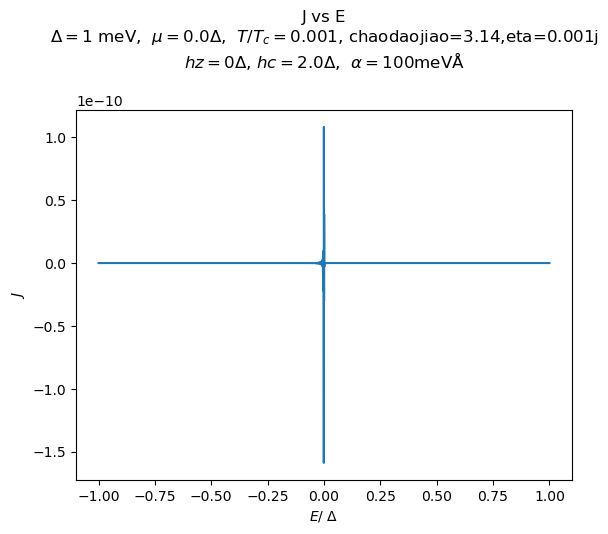

In [14]:
E_set=np.linspace(-1,1,5000)
J_shuchu=[]
for E in E_set:
    G_res, A_DD, Sigma_R, Sigma_L = Gr_DD_666(
        H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E
    )   
    ll=J_E(G_res, T_12, q)
    J_shuchu.append(ll)

plt.plot(E_set,J_shuchu)
plt.ylabel(r"$J$")
plt.xlabel(r"$E$/ $\Delta$")
plt.title(
    f'J vs E\n'
    f'$\\Delta = {dela}$ meV,  $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$, chaodaojiao={chaodaojiao:.2f},eta={epp}\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)

Text(0.5, 1.0, 'J vs E\n$\\Delta = 1$ meV,  $\\mu = 0.0\\Delta$,  $T/T_c = 0.001$, chaodaojiao=3.14,eta=0.001j\n$hz = 0\\Delta$, $hc = 2.0\\Delta$,  $\\alpha = 100$meVÅ\n')

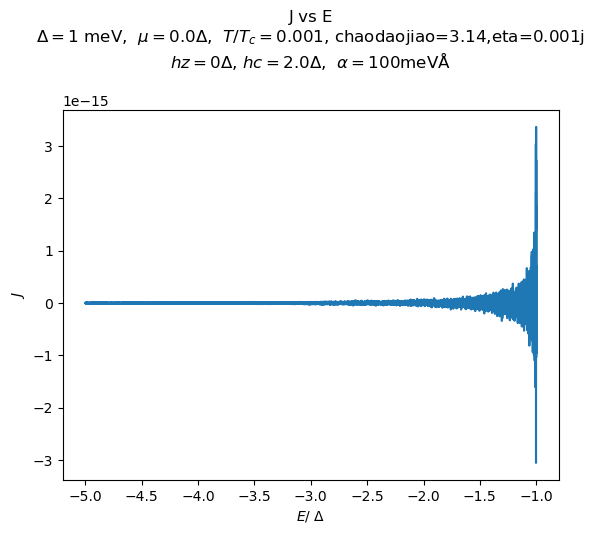

In [23]:
E_set=np.linspace(-5,-1,20000)
J_shuchu=[]
for E in E_set:
    G_res, A_DD, Sigma_R, Sigma_L = Gr_DD_666(
        H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E
    )   
    ll=J_E(G_res, T_12, q)
    J_shuchu.append(ll)

plt.plot(E_set,J_shuchu)
plt.ylabel(r"$J$")
plt.xlabel(r"$E$/ $\Delta$")
plt.title(
    f'J vs E\n'
    f'$\\Delta = {dela}$ meV,  $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$, chaodaojiao={chaodaojiao:.2f},eta={epp}\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)